### Que1.-
In this dataset you have to predict that whether we have to give ATTORNEY to the clients or not (0=Yes, 1=No) based on below factors.
CLMAGE - Age of Client
CLMSEX - Sex of client (0=Male, 1= Female)
SEATBELT - Whether client has Seatbelt or not (0=Yes, 1=No)
CLMINSUR - Whether Client give Insurance or not (0=Yes, 1=No)
LOSS - Loss that client faced

Prepare model by using AdaBoost, XGBoost & CATBoost & Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Claimants.csv


### import required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data into file

In [2]:
df = pd.read_csv('./claimants.csv')
df.head(2)

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891


### exploratory data analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ATTORNEY  1340 non-null   int64  
 1   CLMSEX    1328 non-null   float64
 2   CLMINSUR  1299 non-null   float64
 3   SEATBELT  1292 non-null   float64
 4   CLMAGE    1151 non-null   float64
 5   LOSS      1340 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 62.9 KB


In [4]:
df.isna().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
df.dropna(inplace = True)

In [6]:
df.isna().sum()

ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [7]:
df.corr()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
ATTORNEY,1.000000,0.097475,0.084609,-0.060795,0.001132,-0.225769
CLMSEX,0.097475,1.000000,0.058164,-0.017814,-0.017942,-0.029742
CLMINSUR,0.084609,0.058164,1.000000,0.021217,0.048166,0.019502
SEATBELT,-0.060795,-0.017814,0.021217,1.000000,-0.028343,0.131182
CLMAGE,0.001132,-0.017942,0.048166,-0.028343,1.000000,0.065513
LOSS,-0.225769,-0.029742,0.019502,0.131182,0.065513,1.000000


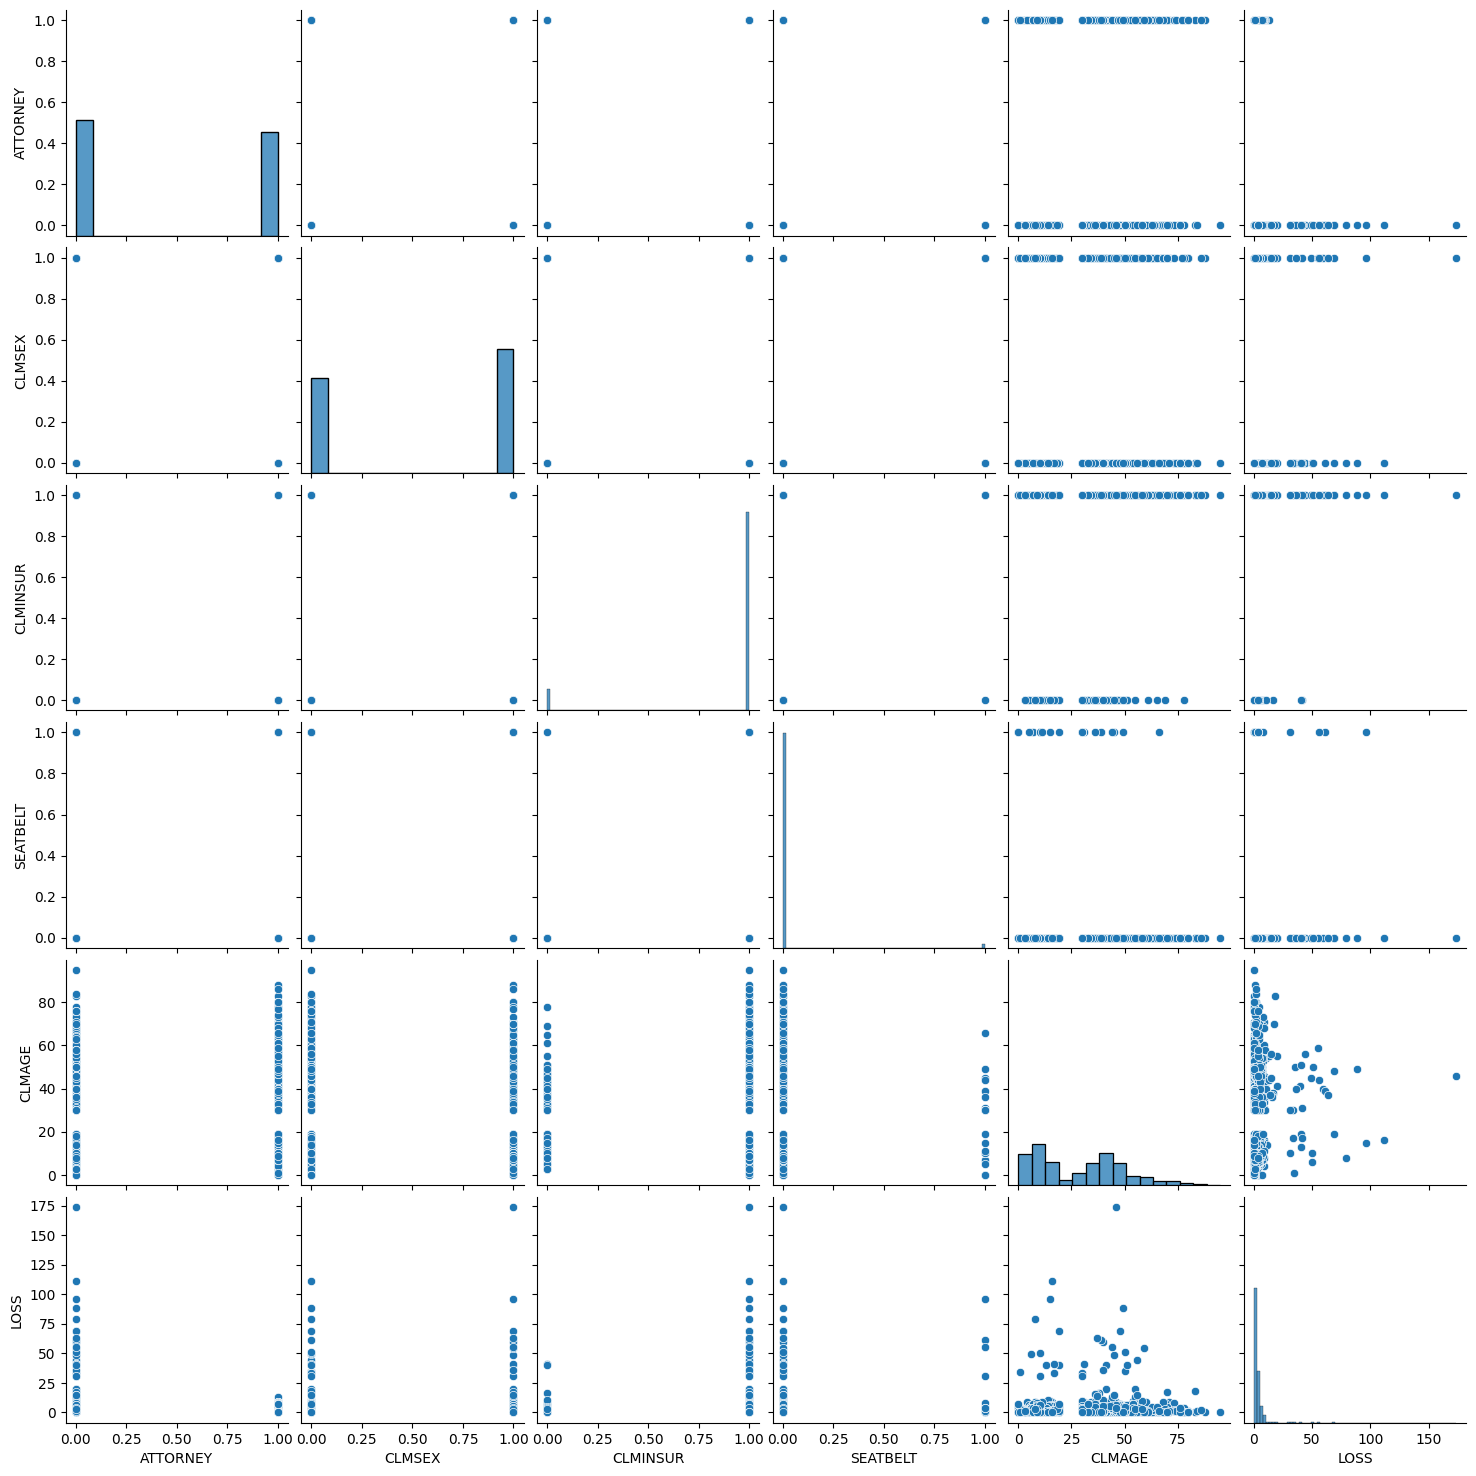

In [8]:
sns.pairplot(df)

<Axes: >

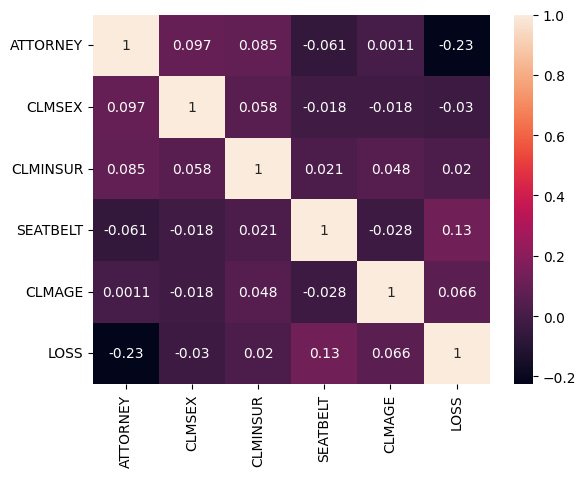

In [9]:
sns.heatmap(df.corr(), annot = True)

In [10]:
df['ATTORNEY'].value_counts()

ATTORNEY
0    578
1    518
Name: count, dtype: int64

### split the data

In [11]:
x = df.drop('ATTORNEY', axis = 1)
y = df['ATTORNEY']

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 42)


### train the model

In [13]:
def AdaBoost():
    from sklearn.ensemble import AdaBoostClassifier

    # create and train the model
    model = AdaBoostClassifier()

    model.fit(x_train, y_train)

    return model

In [14]:
def xgboost_model():
    from xgboost import XGBClassifier

    model = XGBClassifier()
    model.fit(x_train, y_train)
    return model

In [15]:
def catboost_model():
    from catboost import CatBoostClassifier

    model =  CatBoostClassifier()
    model.fit(x_train, y_train)
    return model

### evaluate the model

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return name, accuracy, precision, recall, f1

In [17]:
models = [
    {"name":"AdaBoost", "model": AdaBoost()},
    {"name": "XGBoost", "model": xgboost_model()},
    {"name": "CatBoost", "model":  catboost_model()}
]

Learning rate set to 0.009736
0:	learn: 0.6903135	total: 134ms	remaining: 2m 13s
1:	learn: 0.6875850	total: 135ms	remaining: 1m 7s
2:	learn: 0.6850531	total: 137ms	remaining: 45.4s
3:	learn: 0.6826437	total: 138ms	remaining: 34.4s
4:	learn: 0.6802630	total: 140ms	remaining: 27.8s
5:	learn: 0.6779069	total: 141ms	remaining: 23.4s
6:	learn: 0.6752496	total: 143ms	remaining: 20.2s
7:	learn: 0.6729335	total: 144ms	remaining: 17.9s
8:	learn: 0.6709459	total: 145ms	remaining: 16s
9:	learn: 0.6687741	total: 147ms	remaining: 14.6s
10:	learn: 0.6662822	total: 149ms	remaining: 13.4s
11:	learn: 0.6639088	total: 150ms	remaining: 12.4s
12:	learn: 0.6618615	total: 151ms	remaining: 11.5s
13:	learn: 0.6595681	total: 153ms	remaining: 10.8s
14:	learn: 0.6577688	total: 154ms	remaining: 10.1s
15:	learn: 0.6556695	total: 156ms	remaining: 9.58s
16:	learn: 0.6535686	total: 157ms	remaining: 9.09s
17:	learn: 0.6513842	total: 159ms	remaining: 8.66s
18:	learn: 0.6493615	total: 160ms	remaining: 8.28s
19:	learn: 0

In [18]:
metrics_train = []

for model_info in models:
    metrics_train.append(evaluate_model(model_info['model'], model_info['name'], x_train, y_train))

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.736301,0.719212,0.713936,0.716564
1,XGBoost,0.942922,0.936740,0.941320,0.939024
2,CatBoost,0.795662,0.790404,0.765281,0.777640


In [19]:
metrics_test = []

for model_info in models:
    metrics_test.append(evaluate_model(model_info['model'], model_info['name'], x_test, y_test))

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.681818,0.714286,0.596330,0.650000
1,XGBoost,0.640909,0.656250,0.577982,0.614634
2,CatBoost,0.672727,0.712644,0.568807,0.632653


### Que2.-

The model's main purpose is to predict the 10-year risk of Coronary Heart Disease (CHD). CHD is a disease of the blood vessels supplying the heart. Heart disease has been the leading cause of death worldwide since 1921. In 2008, 7.3 million people died from CHD. 
The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.
Variables
- Sex: male or female(0=female, 1=male)
- Age: Age of the patient
- education: Some high school (1), high school/GED (2), some college/vocational school (3), college (4)
- Current Smoker: whether or not the patient is a current smoker (0=No, 1=Yes)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day
- BP Meds: whether or not the patient was on blood pressure medication 
- Prevalent Stroke: whether or not the patient had previously had a stroke (0=No, 1=Yes)
- Prevalent Hyp: whether or not the patient was hypertensive (0=No, 1=Yes)
- Diabetes: whether or not the patient had diabetes (0=No, 1=Yes)
- Tot Chol: total cholesterol level
- Sys BP: systolic blood pressure 
- Dia BP: diastolic blood pressure
- BMI: Body Mass Index
- Heart Rate: heart rate
- Glucose: glucose level

Prepare model by using AdaBoost, XGBoost & CATBoost.

Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Datasets : framingham.csv


### import required packages

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data

In [21]:
df = pd.read_csv('./framingham.csv')
df.head(2)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0


### exploratory data analysis

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [23]:
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [24]:
df.dropna(inplace = True)

In [25]:
df.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [26]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,0.443685,49.551941,1.980317,0.489065,9.025424,0.030344,0.005741,0.311646,0.027064,236.847731,132.370558,82.917031,25.782802,75.730727,81.852925,0.152269
std,0.496886,8.562029,1.022656,0.499949,11.921590,0.171557,0.075561,0.463229,0.162292,44.097681,22.086866,11.974258,4.065601,11.981525,23.904164,0.359331
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,143.875000,90.000000,28.037500,82.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [27]:
df.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.024412,0.017729,0.206114,0.330322,-0.052124,-0.002312,0.001424,0.013819,-0.070321,-0.045358,0.051872,0.073111,-0.115285,0.002940,0.091688
age,-0.024412,1.000000,-0.159499,-0.210771,-0.189295,0.134732,0.050893,0.306239,0.109092,0.268252,0.388267,0.208283,0.137511,-0.002722,0.118349,0.233983
education,0.017729,-0.159499,1.000000,0.025251,0.013790,-0.013739,-0.030386,-0.078828,-0.039627,-0.013522,-0.124360,-0.058059,-0.137555,-0.064214,-0.031998,-0.063279
currentSmoker,0.206114,-0.210771,0.025251,1.000000,0.773913,-0.051923,-0.038150,-0.108078,-0.041849,-0.051034,-0.134428,-0.115955,-0.159821,0.050841,-0.053242,0.019165
cigsPerDay,0.330322,-0.189295,0.013790,0.773913,1.000000,-0.046504,-0.036286,-0.070460,-0.036961,-0.030400,-0.094781,-0.056746,-0.087395,0.064030,-0.053726,0.052014
BPMeds,-0.052124,0.134732,-0.013739,-0.051923,-0.046504,1.000000,0.113125,0.262910,0.049066,0.094083,0.271263,0.199630,0.105642,0.012889,0.054232,0.089152
prevalentStroke,-0.002312,0.050893,-0.030386,-0.038150,-0.036286,0.113125,1.000000,0.066057,0.009625,0.012736,0.061070,0.055834,0.036496,-0.017019,0.016061,0.048366
prevalentHyp,0.001424,0.306239,-0.078828,-0.108078,-0.070460,0.262910,0.066057,1.000000,0.080556,0.166655,0.697675,0.617734,0.302949,0.146818,0.086942,0.181387
diabetes,0.013819,0.109092,-0.039627,-0.041849,-0.036961,0.049066,0.009625,0.080556,1.000000,0.048451,0.102552,0.050686,0.089009,0.060984,0.614820,0.093431
totChol,-0.070321,0.268252,-0.013522,-0.051034,-0.030400,0.094083,0.012736,0.166655,0.048451,1.000000,0.219925,0.174422,0.121056,0.093053,0.049884,0.091338


### split the data

In [28]:
x = df.drop('TenYearCHD', axis =1)
y = df['TenYearCHD']

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 42)

### train the model

In [30]:
def ada_boost():
    from sklearn.ensemble import AdaBoostClassifier

    model = AdaBoostClassifier()
    model.fit(x_train, y_train)
    return model

In [31]:
def xgboost():
    from xgboost import XGBClassifier

    model = XGBClassifier()
    model.fit(x_train, y_train)
    return model

In [32]:
def catboost():
    from catboost import CatBoostClassifier

    model = CatBoostClassifier()
    model.fit(x_train, y_train)
    return model

### evaluate the model

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return name, accuracy, precision, recall, f1

In [34]:
models = [
    {"name": "AdaBoost", "model":ada_boost()},
    {"name": "XGBoost", "model": xgboost()},
    {"name": "CatBoost", "model": catboost()}
]

Learning rate set to 0.016294
0:	learn: 0.6823556	total: 2.53ms	remaining: 2.53s
1:	learn: 0.6713696	total: 4.87ms	remaining: 2.43s
2:	learn: 0.6605522	total: 7.18ms	remaining: 2.38s
3:	learn: 0.6496418	total: 9.43ms	remaining: 2.35s
4:	learn: 0.6389522	total: 11.6ms	remaining: 2.31s
5:	learn: 0.6293086	total: 13.8ms	remaining: 2.29s
6:	learn: 0.6199822	total: 16.1ms	remaining: 2.28s
7:	learn: 0.6107555	total: 18.6ms	remaining: 2.31s
8:	learn: 0.6027379	total: 21ms	remaining: 2.31s
9:	learn: 0.5944649	total: 23.3ms	remaining: 2.31s
10:	learn: 0.5864891	total: 25.6ms	remaining: 2.3s
11:	learn: 0.5784353	total: 27.7ms	remaining: 2.28s
12:	learn: 0.5709961	total: 30ms	remaining: 2.28s
13:	learn: 0.5646619	total: 32.3ms	remaining: 2.27s
14:	learn: 0.5587650	total: 34.7ms	remaining: 2.27s
15:	learn: 0.5514802	total: 36.9ms	remaining: 2.27s
16:	learn: 0.5455433	total: 39.2ms	remaining: 2.27s
17:	learn: 0.5393017	total: 41.4ms	remaining: 2.26s
18:	learn: 0.5335879	total: 43.7ms	remaining: 2.2

In [35]:
metrics_train = []

for model_info in models:
    metrics_train.append(evaluate_model(model_info['model'], model_info['name'], x_train, y_train))

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1
0,AdaBoost,0.853725,0.705882,0.027586,0.053097
1,XGBoost,0.993506,1.000000,0.956322,0.977673
2,CatBoost,0.910800,1.000000,0.400000,0.571429


In [36]:
metrics_test = []

for model_info in models:
    metrics_test.append(evaluate_model(model_info['model'], model_info['name'], x_test, y_test))

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1
0,AdaBoost,0.833333,0.500000,0.032787,0.061538
1,XGBoost,0.821038,0.363636,0.098361,0.154839
2,CatBoost,0.838798,0.625000,0.081967,0.144928


### Que.3 -

Prepare a model for glass classification using Decision Tree, Random Forest, AdaBoost, XGBoost & CATBoost.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.
Data Description:
- RI : refractive index
- Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
- Mg: Magnesium
- AI: Aluminum
- Si: Silicon
- K:Potassium
- Ca: Calcium
- Ba: Barium
- Fe: Iron
- Type: Type of glass: (class attribute)
 1 -- building_windows_float_processed
 2 --building_windows_non_float_processed
 3 --vehicle_windows_float_processed
 4 --vehicle_windows_non_float_processed (none in this database)
 5 --containers
 6 --tableware
 7 --headlamps

Dataset : Glass.csv


### load the data

In [37]:
df = pd.read_csv('./glass.csv')
df.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1


### exploratory data analysis

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [39]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [40]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


### split the data

In [48]:
x = df.drop(['Type','Ca'], axis =1)
y = df['Type']

In [49]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### train the model

In [61]:
def ada_boost():
    from sklearn.ensemble import AdaBoostClassifier

    model = AdaBoostClassifier()
    model.fit(x_train, y_train)
    return model

In [62]:
def xgboost_model():
    from xgboost import XGBClassifier

    model = XGBClassifier()
    model.fit(x_train, y_train)
    return model

In [63]:
def catboost():
    from catboost import CatBoostClassifier

    model = CatBoostClassifier()
    model.fit(x_train, y_train)
    return model

### evaluate the model

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    return name, accuracy, precision, recall, f1

In [65]:
models = [
    {"name": "AdaBoost", "model":ada_boost()},
    {"name": "XGBoost", "model": xgboost_model()},
    {"name": "CatBoost", "model": catboost()}
]

Learning rate set to 0.072311
0:	learn: 1.7137838	total: 8.72ms	remaining: 8.71s
1:	learn: 1.6495139	total: 12.1ms	remaining: 6.03s
2:	learn: 1.6079449	total: 15ms	remaining: 4.99s
3:	learn: 1.5395569	total: 17.9ms	remaining: 4.47s
4:	learn: 1.4854022	total: 21.5ms	remaining: 4.28s
5:	learn: 1.4417147	total: 24.6ms	remaining: 4.08s
6:	learn: 1.3980158	total: 27.8ms	remaining: 3.95s
7:	learn: 1.3548615	total: 31ms	remaining: 3.85s
8:	learn: 1.3205889	total: 34.3ms	remaining: 3.78s
9:	learn: 1.2855352	total: 37.6ms	remaining: 3.72s
10:	learn: 1.2500437	total: 41.3ms	remaining: 3.72s
11:	learn: 1.2267598	total: 44.3ms	remaining: 3.65s
12:	learn: 1.1881105	total: 47.2ms	remaining: 3.58s
13:	learn: 1.1567569	total: 50.3ms	remaining: 3.54s
14:	learn: 1.1308846	total: 53.8ms	remaining: 3.53s
15:	learn: 1.1111635	total: 56.9ms	remaining: 3.5s
16:	learn: 1.0816622	total: 59.8ms	remaining: 3.46s
17:	learn: 1.0589001	total: 62.8ms	remaining: 3.43s
18:	learn: 1.0398496	total: 65.8ms	remaining: 3.4

In [66]:
metrics_train = []

for model_info in models:
    metrics_train.append(evaluate_model(model_info['model'], model_info['name'], x_train, y_train))

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1'])
metrics_train_df

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Algorithm,Accuracy,Precision,Recall,F1
0,AdaBoost,0.426901,0.383523,0.426901,0.400157
1,XGBoost,1.000000,1.000000,1.000000,1.000000
2,CatBoost,1.000000,1.000000,1.000000,1.000000


In [67]:
metrics_test = []

for model_info in models:
    metrics_test.append(evaluate_model(model_info['model'], model_info['name'], x_test, y_test))

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1'])
metrics_test_df

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Algorithm,Accuracy,Precision,Recall,F1
0,AdaBoost,0.465116,0.418135,0.465116,0.433075
1,XGBoost,0.837209,0.835917,0.837209,0.832101
2,CatBoost,0.837209,0.838998,0.837209,0.833807


### Que.4 

Implement a  AdaBoost, XGBoost & CATBoost model to classify the type of animals in the zoo in to different categories.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Zoo.csv

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv('./Zoo.csv')
df.head(2)

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


### exploratory data analysis

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hair      101 non-null    int64
 1   feathers  101 non-null    int64
 2   eggs      101 non-null    int64
 3   milk      101 non-null    int64
 4   airborne  101 non-null    int64
 5   aquatic   101 non-null    int64
 6   predator  101 non-null    int64
 7   toothed   101 non-null    int64
 8   backbone  101 non-null    int64
 9   breathes  101 non-null    int64
 10  venomous  101 non-null    int64
 11  fins      101 non-null    int64
 12  legs      101 non-null    int64
 13  tail      101 non-null    int64
 14  domestic  101 non-null    int64
 15  catsize   101 non-null    int64
 16  type      101 non-null    int64
dtypes: int64(17)
memory usage: 13.5 KB


In [71]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [73]:
df.corr()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
hair,1.000000,-0.427851,-0.817382,0.878503,-0.198431,-0.473554,-0.154769,0.492531,0.191681,0.441149,-0.104245,-0.280313,0.394009,0.048973,0.207208,0.455020,-0.562384
feathers,-0.427851,1.000000,0.419248,-0.410761,0.656553,-0.058552,-0.104430,-0.613631,0.231403,0.254588,-0.145739,-0.223541,-0.206686,0.292569,0.031586,-0.135934,-0.197520
eggs,-0.817382,0.419248,1.000000,-0.938848,0.376646,0.376244,0.011605,-0.642150,-0.340420,-0.382777,0.098689,0.164796,-0.224918,-0.221090,-0.155610,-0.514650,0.661825
milk,0.878503,-0.410761,-0.938848,1.000000,-0.366765,-0.362613,-0.029721,0.628168,0.384958,0.423527,-0.242449,-0.156328,0.214196,0.210026,0.163928,0.574906,-0.723683
airborne,-0.198431,0.656553,0.376646,-0.366765,1.000000,-0.172638,-0.295181,-0.594311,-0.104718,0.286039,0.008528,-0.251157,0.043712,0.009482,0.063274,-0.349768,0.022677
aquatic,-0.473554,-0.058552,0.376244,-0.362613,-0.172638,1.000000,0.375978,0.053150,0.022463,-0.637506,0.087915,0.604492,-0.360638,-0.034642,-0.224308,-0.111866,0.326639
predator,-0.154769,-0.104430,0.011605,-0.029721,-0.295181,0.375978,1.000000,0.129452,0.051022,-0.262931,0.115391,0.190302,-0.099723,0.018947,-0.309794,0.144790,0.061179
toothed,0.492531,-0.613631,-0.642150,0.628168,-0.594311,0.053150,0.129452,1.000000,0.575085,-0.065690,-0.062344,0.364292,-0.193476,0.310368,0.069430,0.344010,-0.471527
backbone,0.191681,0.231403,-0.340420,0.384958,-0.104718,0.022463,0.051022,0.575085,1.000000,0.207666,-0.246611,0.209499,-0.432856,0.731762,0.101733,0.356976,-0.828845
breathes,0.441149,0.254588,-0.382777,0.423527,0.286039,-0.637506,-0.262931,-0.065690,0.207666,1.000000,-0.120752,-0.617219,0.369868,0.088952,0.124068,0.204125,-0.519308


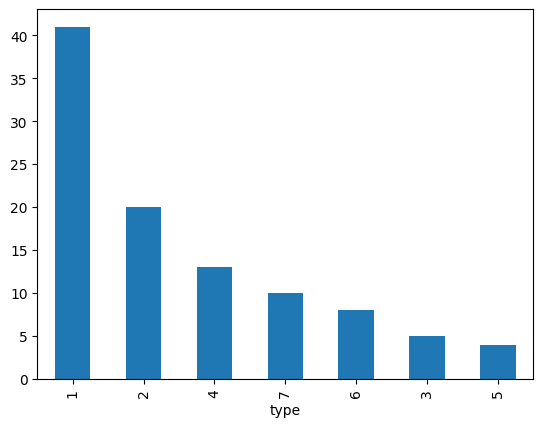

In [78]:
df['type'].value_counts().plot(kind='bar')
plt.show()

### split the data

In [79]:
x = df.drop('type', axis =1)
y = df['type']

In [80]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### train the model

In [88]:
def adaboost():
    from sklearn.ensemble import AdaBoostClassifier

    model = AdaBoostClassifier()
    model.fit(x_train, y_train)

    return model

In [89]:
def xgboost():
    from xgboost import XGBClassifier

    model = XGBClassifier()
    model.fit(x_train, y_train)

    return model

In [90]:
def catboost():
    from catboost import CatBoostClassifier

    model = CatBoostClassifier()
    model.fit(x_train, y_train)

    return model

### evaluate the model

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average = 'weighted')
    recall = recall_score(y, y_pred, average = 'weighted')
    f1 = f1_score(y, y_pred, average = 'weighted')

    return name, accuracy, precision, recall, f1
    

In [95]:
models =[
    {"name": "AdaBoost", "model": ada_boost()},
    {"name": "XGBoost", "model": xgboost()},
    {"name": "CatBoost", "model": catboost()}
]

Learning rate set to 0.069563
0:	learn: 1.8319729	total: 1.99ms	remaining: 1.99s
1:	learn: 1.6910384	total: 7.96ms	remaining: 3.97s
2:	learn: 1.6261623	total: 13.9ms	remaining: 4.61s
3:	learn: 1.5256700	total: 19.9ms	remaining: 4.95s
4:	learn: 1.4307557	total: 25.6ms	remaining: 5.1s
5:	learn: 1.3513383	total: 31.4ms	remaining: 5.2s
6:	learn: 1.2798191	total: 37.2ms	remaining: 5.27s
7:	learn: 1.2338085	total: 43.1ms	remaining: 5.35s
8:	learn: 1.1746801	total: 49ms	remaining: 5.4s
9:	learn: 1.1144506	total: 54.9ms	remaining: 5.43s
10:	learn: 1.0597765	total: 60.9ms	remaining: 5.48s
11:	learn: 1.0148659	total: 66.7ms	remaining: 5.49s
12:	learn: 0.9741447	total: 72.7ms	remaining: 5.52s
13:	learn: 0.9338845	total: 78.5ms	remaining: 5.53s
14:	learn: 0.8962411	total: 84.2ms	remaining: 5.53s
15:	learn: 0.8652616	total: 89.3ms	remaining: 5.49s
16:	learn: 0.8387094	total: 94.4ms	remaining: 5.46s
17:	learn: 0.8095291	total: 99.5ms	remaining: 5.43s
18:	learn: 0.7813015	total: 105ms	remaining: 5.43

In [96]:
metrics_train = []

for model_info in models:

    metrics_train.append(evaluate_model(model_info['model'],model_info['name'], x_train, y_train))

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_train_df

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.8875,0.822321,0.8875,0.846377
1,XGBoost,1.0000,1.000000,1.0000,1.000000
2,CatBoost,1.0000,1.000000,1.0000,1.000000


In [97]:
metrics_test = []

for model_info in models:

    metrics_test.append(evaluate_model(model_info['model'],model_info['name'], x_test, y_test))

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.809524,0.773810,0.809524,0.780952
1,XGBoost,0.952381,0.920635,0.952381,0.933333
2,CatBoost,0.952381,0.920635,0.952381,0.933333


### Que.5

In Churn.csv dataset you have to predict that customer is exited or not based on various factors given in dataset.
Implement a AdaBoost, XGBoost & CATBoost model and calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df = pd.read_csv('Churn.csv')
df.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


### exploratory data analysis

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [109]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [110]:
df.drop(['RowNumber', 'CustomerId', 'Surname'],axis =1, inplace = True)

In [114]:
from sklearn.preprocessing import LabelEncoder

geography_encoder = LabelEncoder()
df['Geography'] = geography_encoder.fit_transform(df['Geography'])
gender_encoder = LabelEncoder()
df['Gender'] = gender_encoder.fit_transform(df['Gender'])

0       0
1       2
2       0
3       0
4       2
       ..
9995    0
9996    0
9997    0
9998    1
9999    0
Name: Geography, Length: 10000, dtype: int64

In [113]:
df.corr()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.007888,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Geography,0.007888,1.000000,0.004719,0.022812,0.003739,0.069408,0.003972,-0.008523,0.006724,-0.001369,0.035943
Gender,-0.002857,0.004719,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512
Age,-0.003965,0.022812,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,0.003739,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.069408,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,0.003972,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.008523,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.006724,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.001369,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


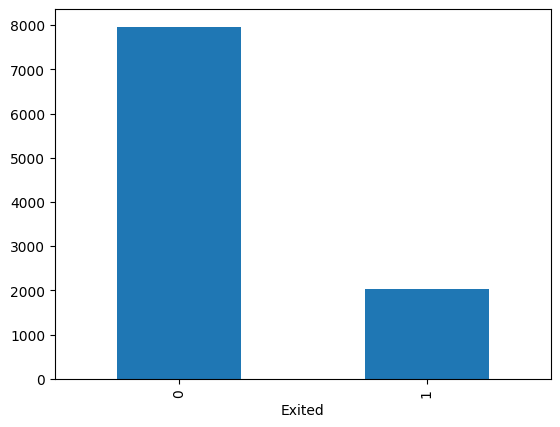

In [115]:
df['Exited'].value_counts().plot(kind='bar')
plt.show()

### split the data

In [116]:
x = df.drop('Exited', axis =1)
y = df['Exited']

In [117]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [118]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

### train the model

In [119]:
def adaboost():
    from sklearn.ensemble import AdaBoostClassifier

    model = AdaBoostClassifier()
    model.fit(x_train, y_train)

    return model

In [120]:
def xgboost():
    from xgboost import XGBClassifier

    model = XGBClassifier()
    model.fit(x_train, y_train)

    return model

In [121]:
def catboost():
    from catboost import CatBoostClassifier

    model = CatBoostClassifier()
    model.fit(x_train, y_train)

    return model

### evaluate the model

In [122]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return name, accuracy, precision, recall, f1
    

In [123]:
models =[
    {"name": "AdaBoost", "model": ada_boost()},
    {"name": "XGBoost", "model": xgboost()},
    {"name": "CatBoost", "model": catboost()}
]

Learning rate set to 0.025035
0:	learn: 0.6724181	total: 5.01ms	remaining: 5s
1:	learn: 0.6530928	total: 9.03ms	remaining: 4.51s
2:	learn: 0.6357871	total: 13.2ms	remaining: 4.37s
3:	learn: 0.6176962	total: 17.3ms	remaining: 4.3s
4:	learn: 0.6011385	total: 21.3ms	remaining: 4.24s
5:	learn: 0.5860065	total: 25.3ms	remaining: 4.19s
6:	learn: 0.5717487	total: 29.3ms	remaining: 4.15s
7:	learn: 0.5584128	total: 33.3ms	remaining: 4.13s
8:	learn: 0.5468963	total: 36.6ms	remaining: 4.03s
9:	learn: 0.5355704	total: 40.4ms	remaining: 4s
10:	learn: 0.5255939	total: 44.6ms	remaining: 4.01s
11:	learn: 0.5175927	total: 48.4ms	remaining: 3.98s
12:	learn: 0.5078640	total: 52.1ms	remaining: 3.96s
13:	learn: 0.5001078	total: 56ms	remaining: 3.94s
14:	learn: 0.4916880	total: 59.9ms	remaining: 3.93s
15:	learn: 0.4831184	total: 63.8ms	remaining: 3.93s
16:	learn: 0.4768155	total: 67.5ms	remaining: 3.9s
17:	learn: 0.4689931	total: 70.9ms	remaining: 3.87s
18:	learn: 0.4631053	total: 74.1ms	remaining: 3.83s
19

In [124]:
metrics_train = []

for model_info in models:

    metrics_train.append(evaluate_model(model_info['model'],model_info['name'], x_train, y_train))

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.854125,0.753994,0.430657,0.548200
1,XGBoost,0.954750,0.963150,0.810827,0.880449
2,CatBoost,0.908000,0.904635,0.617397,0.733912


In [125]:
metrics_test = []

for model_info in models:

    metrics_test.append(evaluate_model(model_info['model'],model_info['name'], x_test, y_test))

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.8580,0.726141,0.445293,0.552050
1,XGBoost,0.8555,0.683099,0.493639,0.573117
2,CatBoost,0.8670,0.743295,0.493639,0.593272
